## Análisis de riesgo financiero

### Librerías

In [2]:
import pandas as pd
import duckdb
import os
import matplotlib.pyplot as plt

Se genera la lista de archivos

In [3]:
data_folder = 'data'

tables = os.listdir(data_folder)

files = {}
for t in tables:
    if t[-3:] == 'csv':
        files[t[:-4]] = t


Se cargan las tablas en duckdb con persistencia en el archivo financial_data.ducdb

In [4]:
conn = duckdb.connect('data/financial_data.duckdb') # o duckdb.connect('____.duckdb') para persistir

for table, file in files.items():
    try:
        conn.execute(f"""
            CREATE TABLE {table} AS 
            SELECT * FROM read_csv_auto('data/{file}')
        """)
    except:
        print('Hubo error en la carga de tablas o las tablas ya han sido cargadas')

# Verificar qué tablas quedaron cargadas
conn.execute("SHOW TABLES").fetchdf()

,name
0,credit_history
1,customers
2,financial_profile
3,loan_applications
4,loan_decisions
5,new_loan_outcomes
6,new_loans
7,new_payment_history
8,payment_history
9,previous_loans


Se pueden ejecutar consultas SQL con el método execute de la conexión o con jupysql directamente escribiendo SQL con la cabecer %%sql y df << para asignar el resultado a un dataframe de pandas

In [5]:
conn.execute(
    f"""
    SELECT * FROM customers LIMIT 5;
    """
).fetchdf()

,customer_id,birth_date,gender,education,marital_status,dependents
0,1,1975-12-31,Female,University,Married,0
1,2,1973-12-31,Female,Secondary,Single,2
2,3,1983-12-31,Female,Secondary,Divorced,0
3,4,1987-12-31,Female,Secondary,Married,2
4,5,1975-12-31,Female,Secondary,Single,0


Se trabajará con jupysql para instalar utilizar: pip install jupysql duckdb-engine.

A continuación la carga de la librería, la configuración para obtener dataframes de pandas como salida de los quieries y suprimir mensajes

Finalmente se asocia la conexión de duckdeb con sql

In [8]:
%load_ext sql

%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
%config SqlMagic.displaycon = False

%sql conn --alias duckdb

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [ ]:
%%sql
customers <<

SELECT * FROM customers;

In [14]:
customers.head()

,customer_id,birth_date,gender,education,marital_status,dependents
0,1,1975-12-31,Female,University,Married,0
1,2,1973-12-31,Female,Secondary,Single,2
2,3,1983-12-31,Female,Secondary,Divorced,0
3,4,1987-12-31,Female,Secondary,Married,2
4,5,1975-12-31,Female,Secondary,Single,0


In [15]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     20000 non-null  int64         
 1   birth_date      20000 non-null  datetime64[us]
 2   gender          20000 non-null  object        
 3   education       20000 non-null  object        
 4   marital_status  20000 non-null  object        
 5   dependents      20000 non-null  int64         
dtypes: datetime64[us](1), int64(2), object(3)
memory usage: 937.6+ KB


No hay valores nulos en la tabla customers

Distribuciones de clientes en las distintas categorías.

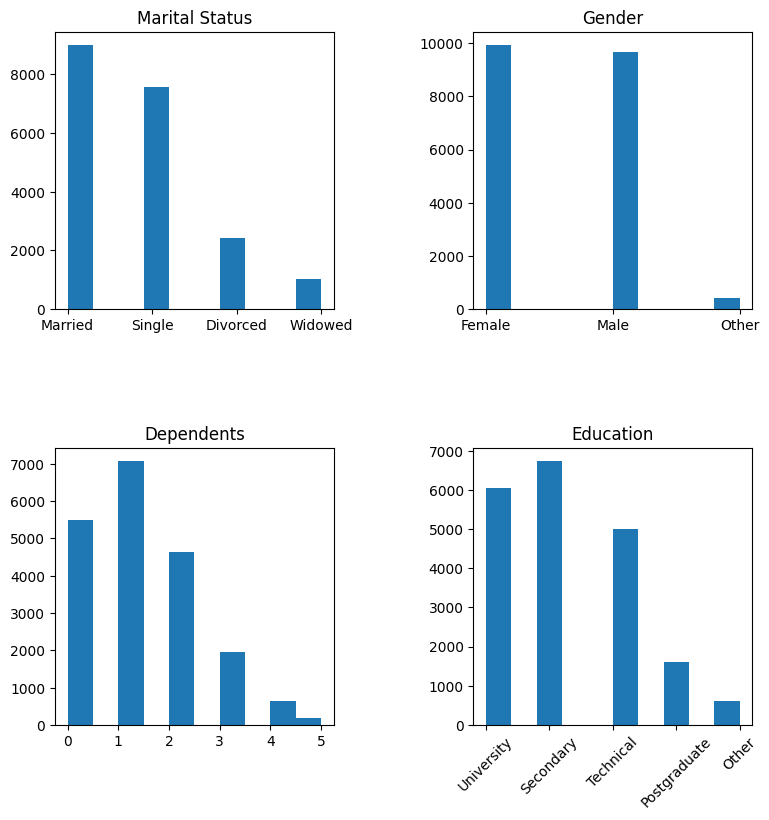

In [49]:
plt.figure(figsize=(9, 9))

plt.subplot(221)
plt.hist(x = customers['marital_status'])
plt.title('Marital Status')

plt.subplot(222)
plt.hist(x = customers['gender'])
plt.title('Gender')

plt.subplot(223)
plt.hist(x = customers['dependents'])
plt.title('Dependents')

plt.subplot(224)
plt.hist(x = customers['education'])
plt.title('Education')
plt.xticks(rotation=45)

plt.subplots_adjust(hspace = 0.5, wspace = 0.5)

plt.show()

In [52]:
%%sql
previous_loans <<

SELECT * FROM previous_loans;

In [53]:
previous_loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16637 entries, 0 to 16636
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   loan_id               16637 non-null  int64         
 1   customer_id           16637 non-null  int64         
 2   loan_date             16637 non-null  datetime64[us]
 3   loan_amount           16637 non-null  float64       
 4   term_months           16637 non-null  int64         
 5   annual_interest_rate  16637 non-null  float64       
 6   loan_status           16637 non-null  object        
 7   default_date          16637 non-null  object        
dtypes: datetime64[us](1), float64(2), int64(3), object(2)
memory usage: 1.0+ MB


In [61]:
%%sql
term_loans <<

SELECT term_months, COUNT(*) AS loans 
FROM previous_loans 
WHERE loan_status = 'Defaulted'
GROUP BY term_months
ORDER BY term_months;

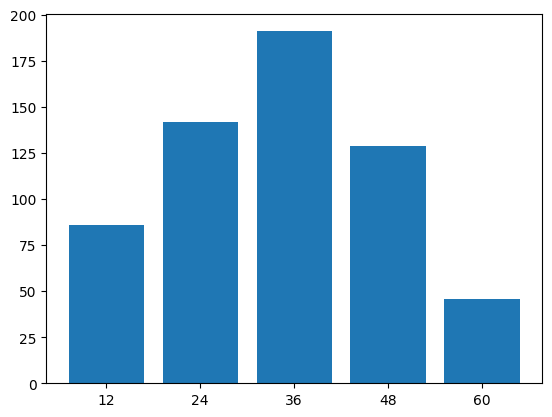

In [69]:
plt.bar(x = term_loans['term_months'].astype('str'), height= term_loans['loans'])
plt.show()